In [100]:

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def gal_to_cel(l, b):
    c = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')
    return c.icrs.ra.degree, c.icrs.dec.degree

ROI center in Galactic Coordintes = 13, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 13.0 0.0 
CRPIX : 720.0 720.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1440  1440
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (725, 739)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (12.88888887, 0.03333333)>
Peak intensity value: 43.9280196840234


(273.47050143305205, -17.661928870744514)

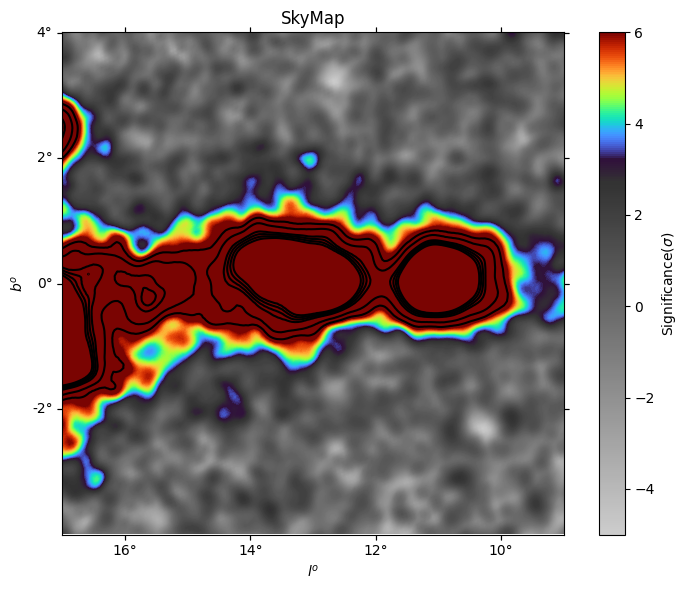

In [101]:
# filename = '/Users/rishi/Documents/Analysis/palmer/aerie-apps_bin4-9__allsky_1024_i2.5_r0.0_p1.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/2027/fitfiles/fittingskymap.fits'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p5-index2p7-padding1p0-bins_8910_GP.fits'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p0-index2p7-padding1p0-bins_8910_GP.fits'
filename ='/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
x = 13
y = 0
# x = 357.3
# y =  42.7
xlength =  4
ylength = 4
coord_sys = 'G' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)
gal_to_cel(x, y)

ROI center in Celestial Coordintes = 230, 28
Loading Celestial Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---MOL' 'DEC--MOL' 
CRVAL : 230.0 28.0 
CRPIX : 1800.0 1800.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00277777777777777 0.002777777777777778 
NAXIS : 3600  3600
Fits File loaded
Degrees per pixel: 0.002777777777777778 
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (1681, 2136)
Peak intensity sky location: <SkyCoord (ICRS): (ra, dec) in deg
    (228.82564385, 27.69989336)>
Peak intensity value: 33.67956430348725


(135.27576445124518, -0.9494740089444768)

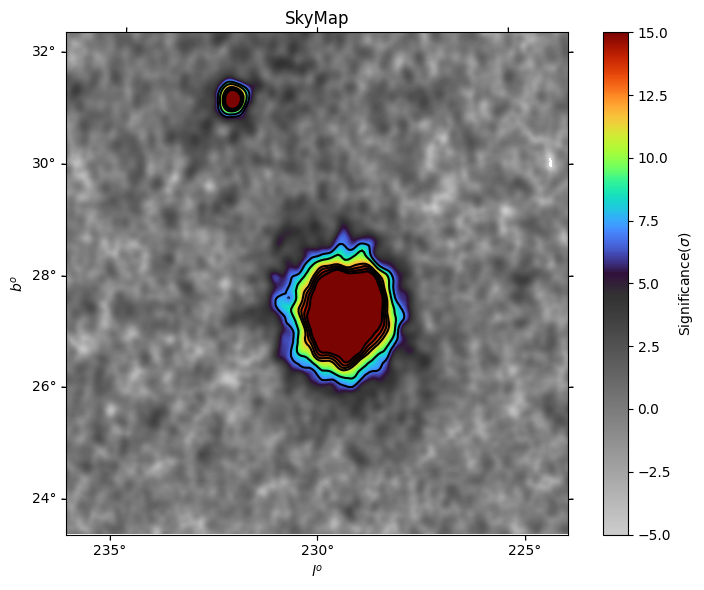

In [145]:
filename ='/Users/rishi/Documents/Analysis/data/map.fits'
filename = '/Users/rishi/Documents/Analysis/AstroImageDetection/map.fits'
x = 230
y = 28
xlength =  10
ylength = 10
coord_sys = 'C' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=5, vmin=-5, vmax=15, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)
gal_to_cel(x, y)

ROI center in Galactic Coordintes = 40.5, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 40.5 0.0 
CRPIX : 540.0 540.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1080  1080
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (394, 555)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (40.41110452, -0.80556213)>
Peak intensity value: 66.05535540393265


(286.32637083823437, 6.731402016860149)

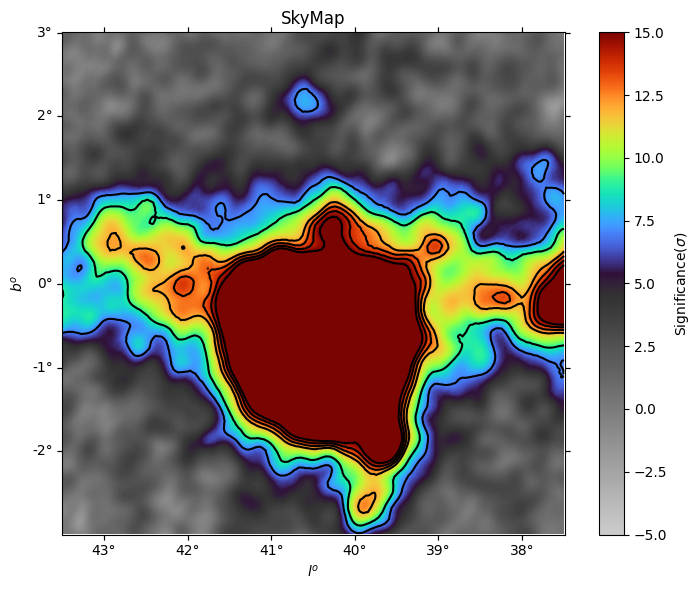

In [305]:
filename ='/Users/rishi/Documents/Analysis/data/map.fits'
filename ='/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
x = 40.5
y = 0
xlength =  3
ylength = 3
coord_sys = 'G' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=5, vmin=-5, vmax=15, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)
gal_to_cel(x, y)

In [261]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


In [262]:
# Preprocessing Step: Floor the image for analysis
print(np.min(array))
print(np.max(array))
if np.min(array) < -6:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

-2.0311751633066977
66.05535540393265


Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (394, 555)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (40.41110452, -0.80556213)>
Peak intensity value: 66.05535540393265


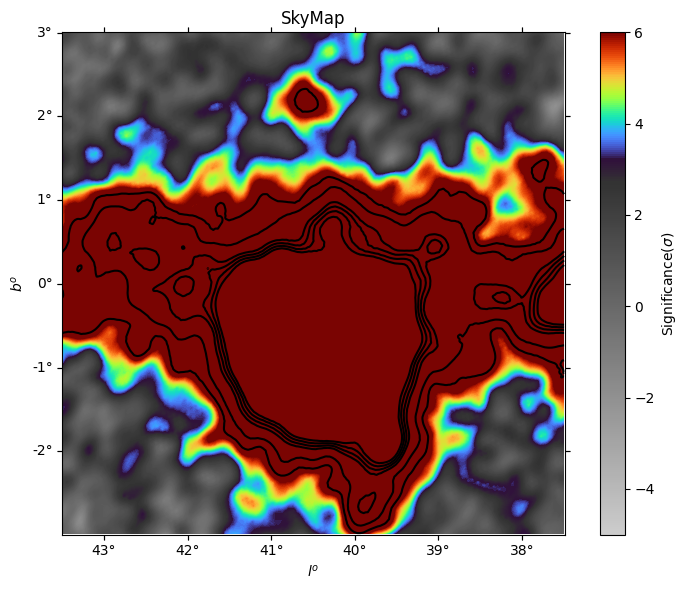

In [263]:
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

Length of bins=1166


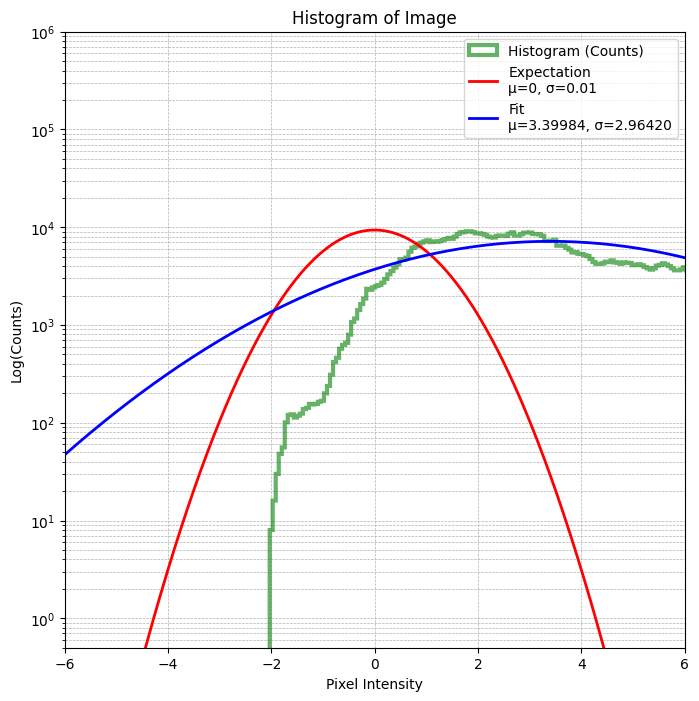

In [264]:
# Calculate the 1D histogram of the image
pixels = array.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
plt.ylim(0.5, 1e6)
plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>, <WCSAxes: >)

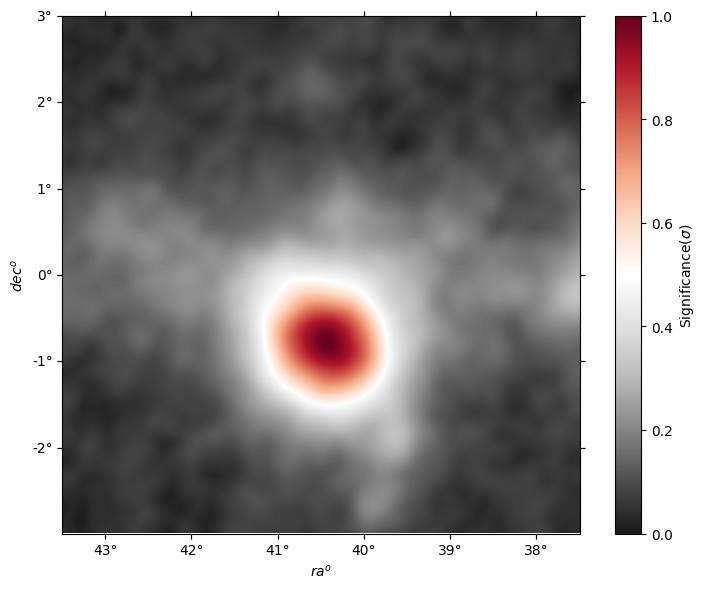

In [265]:
#Normalize the image between 0 and 1 for analysis

image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title=None, hotspots=None, save_dir=None, pdf=False, cmap='RdGy_r', figsize=(10, 6))

0.0327582238634327 0.7985840168679936


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Smeared Image with radius 0.3$^\\degree$'}>)

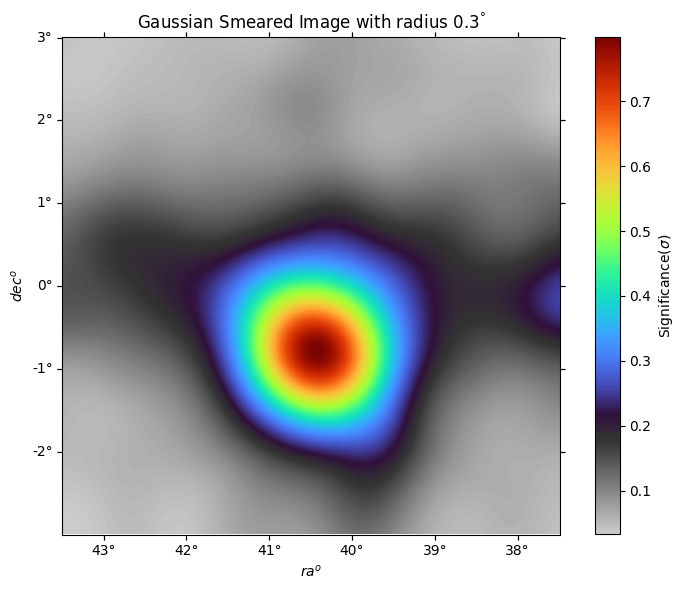

In [302]:
#Smearing Image with a gaussian for visualizing 
image_tmp = norm_image
smear_radius = 0.3
smear_image = gaussian(image_tmp, sigma=smear_radius/pixel_size)
print(np.min(smear_image), np.max(smear_image))
make_plots(smear_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=np.min(smear_image), vmax=np.max(smear_image), title=f"Gaussian Smeared Image with radius {smear_radius}$^\degree$", cmap='ult')

53.99999999999999


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

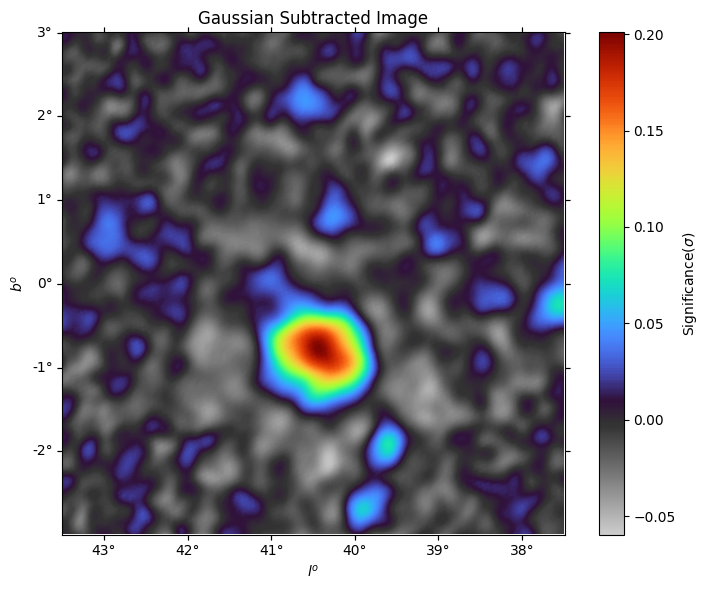

In [267]:
# Find the Difference of Gaussian (DoG) Image
psf=0.3  #PSF of the dec band
print(psf/pixel_size)
dog_image = difference_of_gaussians(norm_image, 1, psf/pixel_size)
# dog_image = gaussian(dog_image)
make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image', cmap='ult')#, labels=['4hawc'])

Significant deviation from Gaussian on positive side at:68,  0.02970


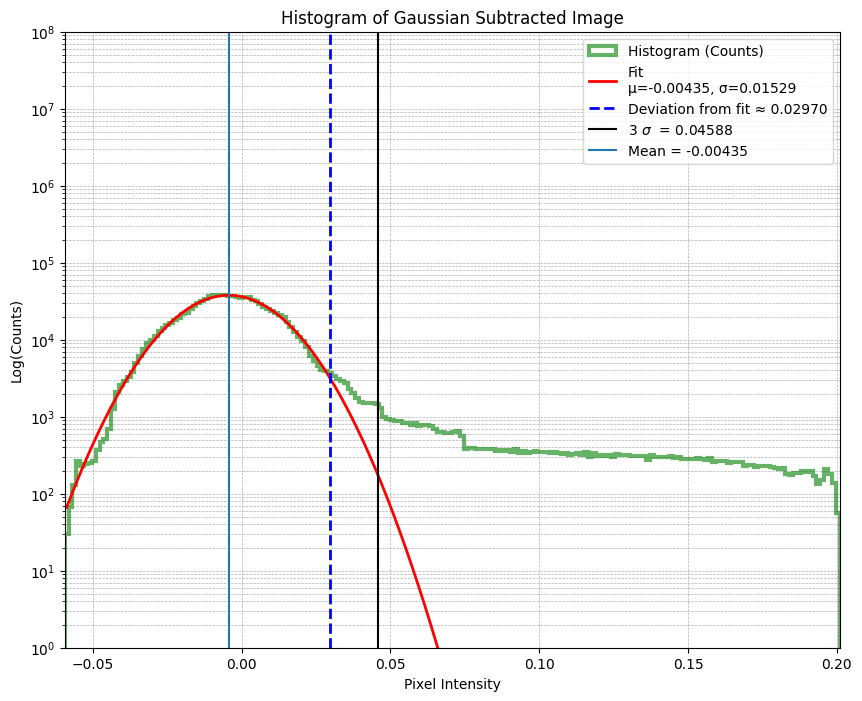

In [268]:
# Calculate the 1D histogram of the DoG Image

pixels = dog_image.flatten()
sigma_resid2 = np.std(dog_image)


counts, bin_edges = np.histogram(pixels, bins=200, range=(np.min(pixels), np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(np.min(bin_edges), np.max(bin_edges), 200)
y_exp = gaussian_fit(x_exp, counts.max(), -0.1, 0.01)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
x_fit = np.linspace(bin_centers[0], bin_centers[-1], 500)
y_fit = gaussian_fit(x_fit, *popt)


fit_interp = interp1d(x_fit, y_fit, bounds_error=False, fill_value=0)
gaussian_at_bins = fit_interp(bin_centers)

# Compute deviation mask: where histogram exceeds Gaussian expectation significantly
deviation_mask = (bin_centers > popt[1]) & (counts > 1.1 * gaussian_at_bins)

for i in range(len(deviation_mask)):
    if np.all(deviation_mask[i:]):
        j = i
        break
deviation_location = bin_centers[j]
print(f"Significant deviation from Gaussian on positive side at:{j},  {deviation_location:.5f}")

sigma_resid = popt[2]
deviation = 3*sigma_resid
plt.figure(figsize=(10, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=200, range=(np.min(pixels), np.max(pixels)),  color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)',histtype='step', linewidth=3)
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
if np.any(deviation_mask):
    plt.axvline(deviation_location, color='blue', linestyle='--', linewidth=2, 
                label=f'Deviation from fit ≈ {deviation_location:.5f}')
plt.axvline(deviation, label=f'3 $\sigma$  = {3*popt[2]:.5f}', color='black')
plt.axvline(popt[1], label=f'Mean = {popt[1]:.5f}')
plt.yscale('log')
plt.ylim(1, 1e8)
plt.xlim(np.min(bin_edges), np.max(bin_edges))
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Gaussian Subtracted Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig("1DHist.pdf")
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

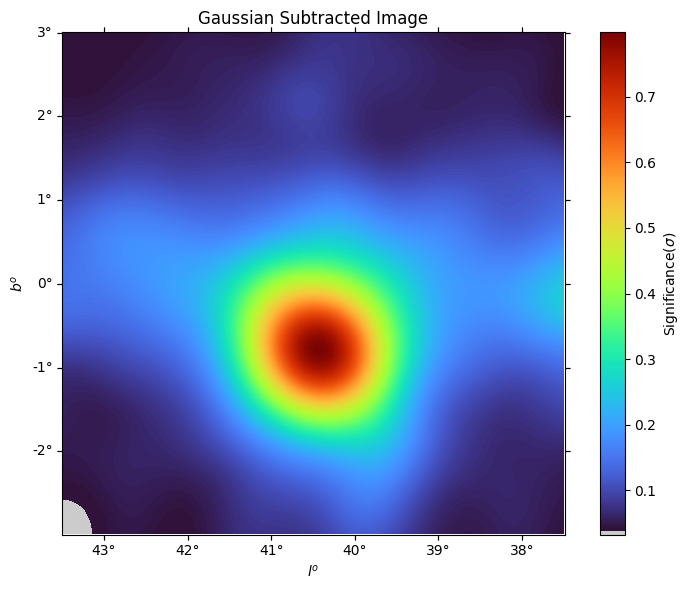

In [269]:
lowfreq_image=norm_image-dog_image
lowfreq_image = gaussian(lowfreq_image, sigma=3)
make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#, figsize=(20, 10))

In [270]:
# Find the blobs from the DoG image
threshold_val = 0.01
ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))
ext_blobs = blob_dog(dog_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < psf/pixel_size]
ext_blobs = ext_blobs[ext_blobs[:, 2] > psf/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))

Number of point source blobs= 35
Number of ext source blobs= 6
Number of point source blobs= 35
Number of ext source blobs= 0


In [271]:
# DoG Image Intensity Filtering
deviation=deviation_location
intensity_min = deviation
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ext = ", len(ext_filtered_blobs))

Blob Intensity 0.18360602561790743, Coords (287.00249958843386 deg, 6.264751747740928 deg), Radius 46.08000000000001, Pixel Radius 0.25600000000000006
Blob Intensity 0.06403329729293598, Coords (287.6306802598905 deg, 5.045040791673048 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.05545165596293105, Coords (288.4072304988278 deg, 4.942722116010078 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.04095032960714244, Coords (285.4949079632391 deg, 6.875926331219014 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.04311008496726679, Coords (284.42224358298574 deg, 7.796450723189744 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.030136814456988004, Coords (285.16331774428716 deg, 5.652318533065135 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.03463105976243436, Coords (286.95581895254793 deg, 9.180157531899141 deg), Radius 28.8, Pixel Radius 0.16
No of ps =  7
No of ext =  0


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

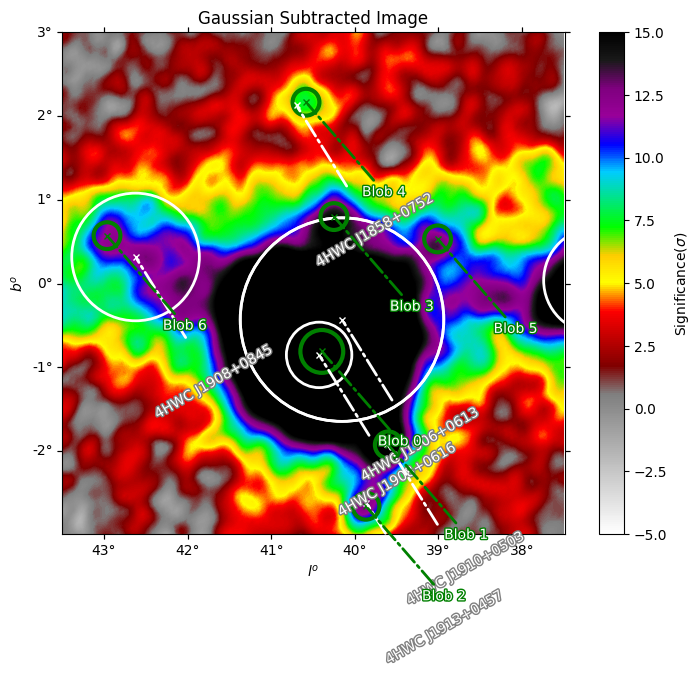

In [272]:
blobs_dict = {
    'psblobs': ps_filtered_blobs,
    'extblobs': ext_filtered_blobs,
}
make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap=milagro, labels=['4hawc'])

In [273]:
# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))

Blob Intensity 63.6307650782896, Coords (287.00249958843386 deg, 6.264751747740928 deg), Radius 46.08000000000001, Pixel Radius 0.25600000000000006
Blob Intensity 18.43236309601205, Coords (287.6306802598905 deg, 5.045040791673048 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 11.934273815767417, Coords (288.4072304988278 deg, 4.942722116010078 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 14.576763987120508, Coords (285.4949079632391 deg, 6.875926331219014 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 7.346140259616794, Coords (284.42224358298574 deg, 7.796450723189744 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 12.38608302490002, Coords (285.16331774428716 deg, 5.652318533065135 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 11.699272398756422, Coords (286.95581895254793 deg, 9.180157531899141 deg), Radius 28.8, Pixel Radius 0.16
No of ps =  7
No of ext =  0


(<Figure size 2000x1000 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

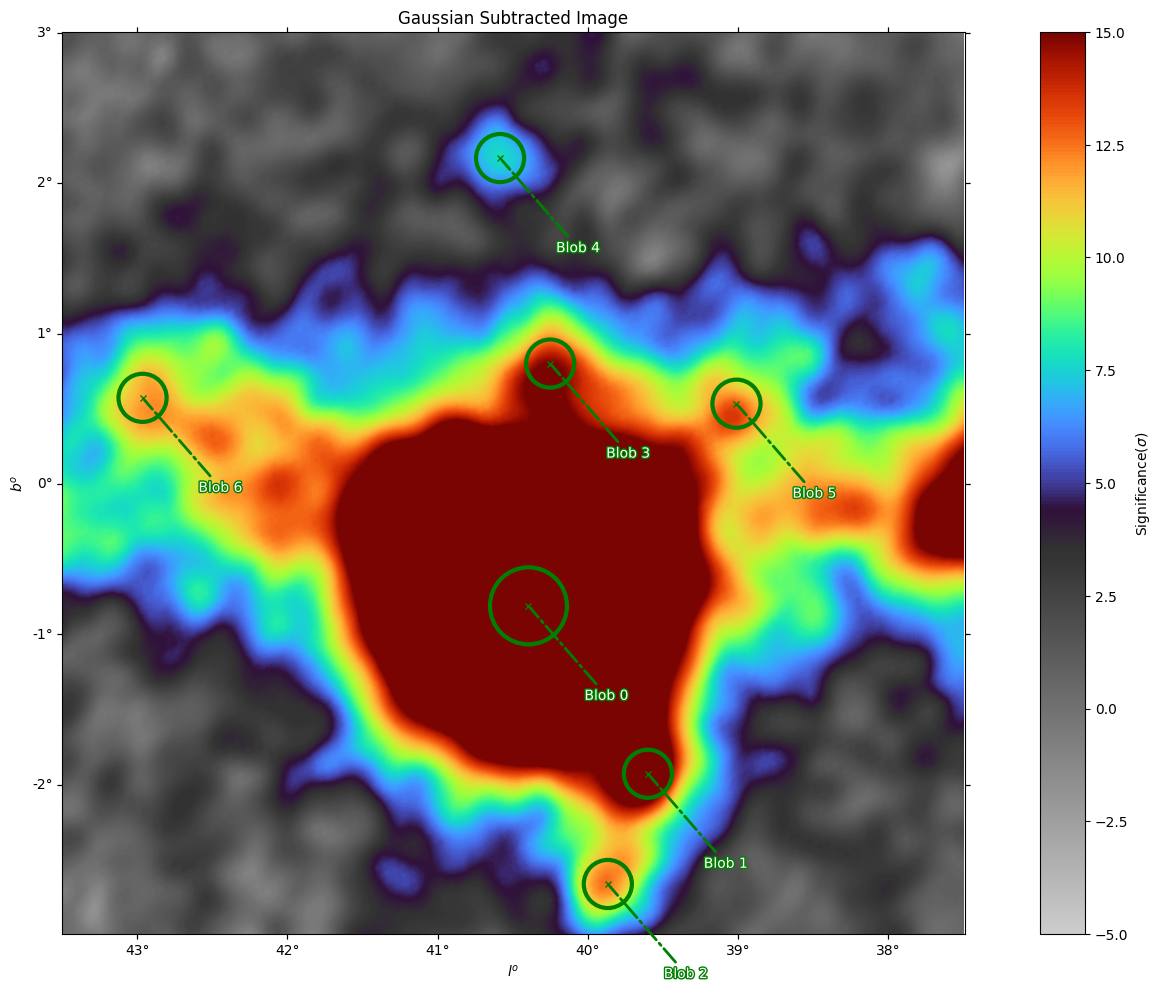

In [274]:
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}

# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])
make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict,title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'], figsize=(20, 10))

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

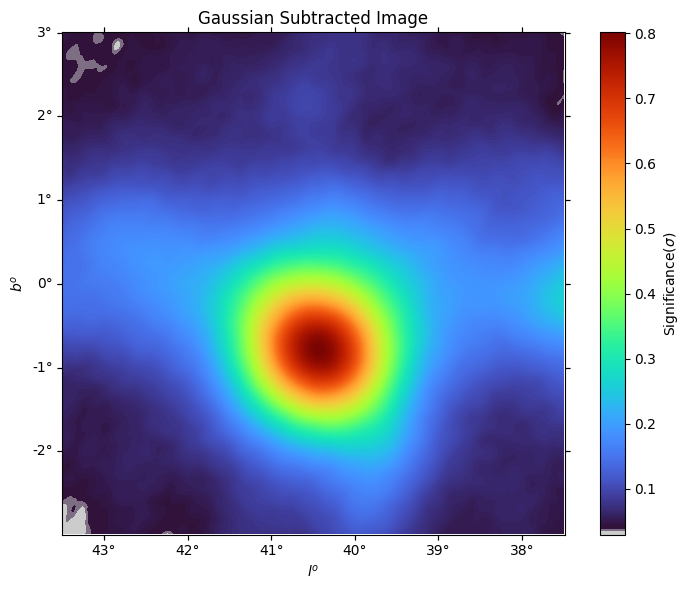

In [275]:
lowfreq_image=norm_image-gaussian(dog_image, sigma=8)
lowfreq_image = gaussian(lowfreq_image, sigma=3)

make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,

In [276]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs4 = blob_dog(lowfreq_image,min_sigma=0.4/pixel_size, max_sigma=0.8/pixel_size, threshold=0.001, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs4))

Number of ext source blobs= 3


Blob Intensity 54.55989934248178, Coords (286.9732779126439 deg, 6.317359468195957 deg), Radius 115.2, Pixel Radius 0.64
Blob Intensity 11.19601181633781, Coords (286.9742721854596 deg, 8.901553796981574 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 3.7973501378086634, Coords (283.9760104960765 deg, 7.822726688768516 deg), Radius 72.0, Pixel Radius 0.4


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

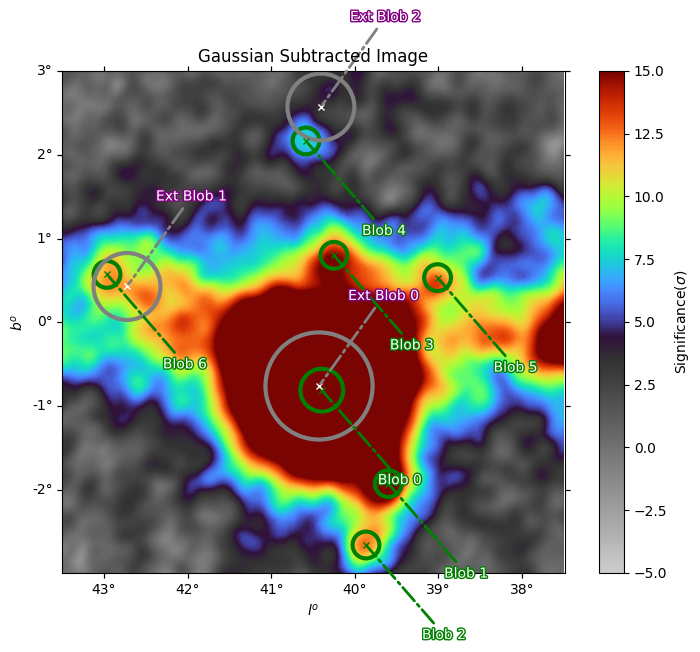

In [277]:
# Filter the Gaussian Blobs from above
ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 3, wcs, pixel_size)

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs4,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['mp'])

In [278]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs2 = blob_dog(lowfreq_image,min_sigma=0.8/pixel_size, max_sigma=1.5/pixel_size, threshold=0.005, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs2))

Number of ext source blobs= 1


Blob Intensity 49.52467952689309, Coords (286.93854075908837 deg, 6.335258922036364 deg), Radius 144.0, Pixel Radius 0.8


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

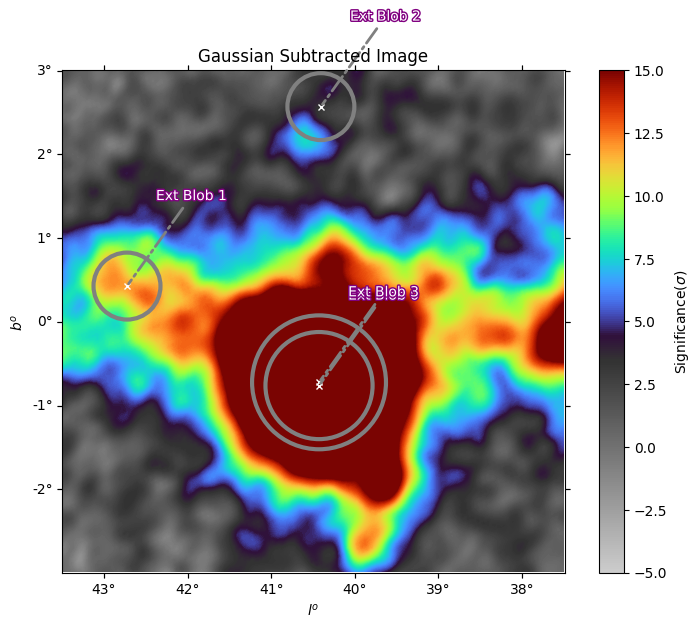

In [279]:
# Filter the Gaussian Blobs from above
ext_filtered_blobs2, ext_filtered_coords2, ext_filtered_radius2 = blob_filter_intensity(ext_blobs2, array, 4.5, wcs, pixel_size)
temp_ext = ext_filtered_blobs4+ext_filtered_blobs2
blobs_dict = {
    # 'psblobs': ps_filtered_blobs2,
    # 'extblobs': ext_filtered_blobs2,
    'extblobs': temp_ext,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult')#, labels=['4hawc'])

In [280]:
from astropy.coordinates import SkyCoord
import astropy.units as u

def remove_overlapping_ext_sources(primary_coords, candidate_coords, threshold_deg=0.3):

    primary = SkyCoord([c.ra.deg for c in primary_coords] * u.deg,
                       [c.dec.deg for c in primary_coords] * u.deg)
    filtered_candidates = []

    for cand in candidate_coords:
        sep = cand.separation(primary)
        if np.all(sep.deg >= threshold_deg):
            filtered_candidates.append(cand)

    return filtered_candidates


def filter_overlapping_sources(coords, radii, radius_to_sigma, name_prefix="Drip", max_distance_deg=0.5):

    df = pd.DataFrame({
        'Names': [f'{name_prefix}{i}' for i in range(len(coords))],
        'ra': [c.ra.deg for c in coords],
        'dec': [c.dec.deg for c in coords],
        'Circle Radius': radii,
    })
    df['Sigma Radius'] = [radius_to_sigma(r) for r in radii]

    keep = np.ones(len(df), dtype=bool)
    skycoords = SkyCoord(ra=df['ra'].values * u.deg, dec=df['dec'].values * u.deg)

    for i in range(len(df)):
        if not keep[i]:
            continue
        sep = skycoords[i].separation(skycoords[i+1:]).deg
        for j_offset, dist in enumerate(sep):
            j = i + 1 + j_offset
            if not keep[j]:
                continue
            if dist < max_distance_deg:
                r1 = df.loc[i, 'Sigma Radius']
                r2 = df.loc[j, 'Sigma Radius']
                if r1 > 0.1 and r2 <= 0.1:
                    keep[j] = False
                elif r2 > 0.1 and r1 <= 0.1:
                    keep[i] = False
                else:
                    keep[j if r1 < r2 else i] = False

    return df[keep].reset_index(drop=True)
def remove_overlapping_ext_sources_with_indices(primary_coords, candidate_coords, threshold_deg=1):
    primary = SkyCoord([c.ra.deg for c in primary_coords] * u.deg,
                       [c.dec.deg for c in primary_coords] * u.deg)

    keep_indices = []
    for idx, cand in enumerate(candidate_coords):
        sep = cand.separation(primary)
        if np.all(sep.deg >= threshold_deg):
            keep_indices.append(idx)
    return keep_indices

from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

def remove_ext_sources_with_radius_overlap(t_coords, t_radii, candidate_coords, candidate_radii):
    """
    Removes candidate sources that overlap with any t_coord based on combined radius.

    Parameters:
    ----------
    t_coords : list of SkyCoord
        Existing sources (points or extended).
    t_radii : list of float
        Angular radii (in degrees) for t_coords.
    candidate_coords : list of SkyCoord
        Candidate extended sources to filter.
    candidate_radii : list of float
        Radii for candidate_coords (degrees).

    Returns:
    -------
    keep_indices : list of int
        Indices of candidate_coords that do NOT overlap with any t_coords.
    """
    assert len(candidate_coords) == len(candidate_radii)
    assert len(t_coords) == len(t_radii)

    t_sky = SkyCoord(ra=[c.ra.deg for c in t_coords] * u.deg,
                     dec=[c.dec.deg for c in t_coords] * u.deg)

    keep_indices = []
    for idx, (cand, r_cand) in enumerate(zip(candidate_coords, candidate_radii)):
        sep = cand.separation(t_sky).deg
        combined_radius = r_cand + np.array(t_radii)
        overlaps = sep <= combined_radius
        if not np.any(overlaps):
            keep_indices.append(idx)

    return keep_indices




In [281]:
all_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3 + ext_filtered_coords4
all_radii = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3 + ext_filtered_radius4

filtered_df = filter_overlapping_sources(all_coords, all_radii, radius_to_sigma)

In [300]:
all_radii

[0.25600000000000006, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.8, 0.64, 0.4, 0.4]

In [282]:
t_coords = ps_filtered_coords2 + ext_filtered_coords2
t_radii = ps_filtered_radius2 + ext_filtered_radius2

# Filter ext group 4
valid_idx = remove_ext_sources_with_radius_overlap(
    t_coords, t_radii,
    ext_filtered_coords4, ext_filtered_radius4
)

# Apply filtering
ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
ext_filtered_blobs4  = [ext_filtered_blobs4[i]  for i in valid_idx]

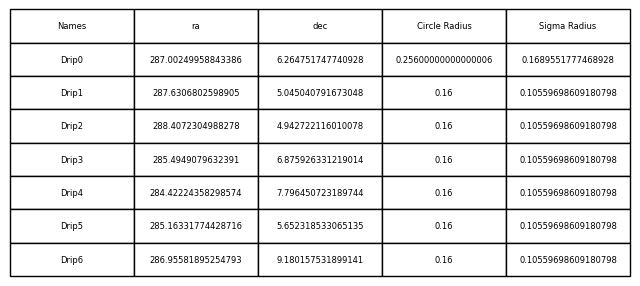

In [283]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
287.00249958843386 6.264751747740928
287.6306802598905 5.045040791673048
288.4072304988278 4.942722116010078
285.4949079632391 6.875926331219014
284.42224358298574 7.796450723189744
285.16331774428716 5.652318533065135
286.95581895254793 9.180157531899141


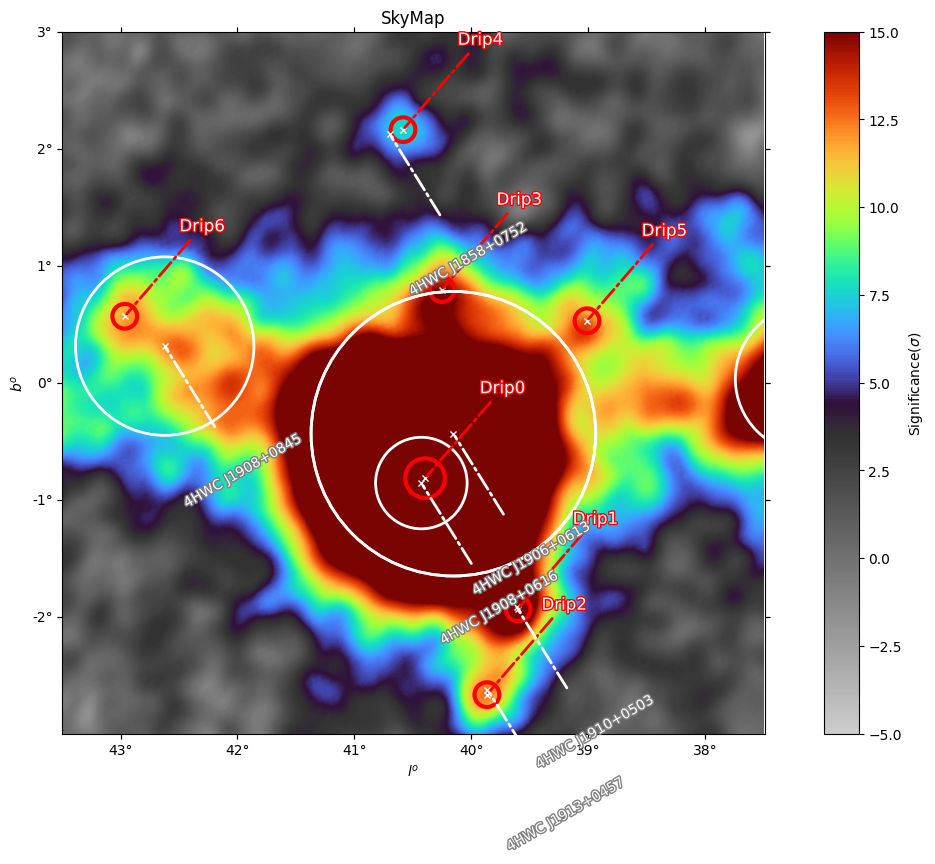

In [298]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs2,
}
# make_plots(array, wcs, pixel_size, coordsys='G', hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc', '4fgl', 'hgps', 'psr', 'snr'], figsize=(20, 10))
# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['N'], figsize=(20, 10))
make_plots(array, wcs, pixel_size,threshold=4, coordsys='G',hotspots=seed_final, title=f'SkyMap', cmap='ult', labels=['4hawc'], save_dir='./', figsize=(16, 8))
plt.savefig("J2027Result.pdf", bbox_inches='tight')

In [288]:
from astropy.coordinates import ICRS
from astroquery.simbad import Simbad

In [289]:
otype_dict = {
    'SN*': 'SuperNova',
    'SN?': 'SuperNova',
    'XB*': 'X-ray Binary',
    'XB?': 'X-ray Binary',
    'LXB': 'Low Mass X-ray Binary',
    'LXB?': 'Low Mass X-ray Binary',
    'HXB': 'High Mass X-ray Binary',
    'HXB?': 'High Mass X-ray Binary',
    'Psr': 'Pulsar',
    'SFR': 'Star Forming Region',
    'HII': 'HII Region',
    'SNR': 'SuperNova Remnant',
    'SR?': 'SuperNova Remnant',
    'gam': 'Gamma-ray Source',
    'gB': 'Gamma-ray Burst',
    'X': 'X-ray Source',
    'ULX': 'Ultra-luminous X-ray Source',
    'UX?': 'Ultra-luminous X-ray Source',
}
Simbad.add_votable_fields('parallax', 'mesdistance', 'otype') 
Simbad.get_votable_fields()

['basic.main_id',
 'basic.ra',
 'basic.dec',
 'basic.coo_err_maj',
 'basic.coo_err_min',
 'basic.coo_err_angle',
 'basic.coo_wavelength',
 'basic.coo_bibcode',
 'basic.otype',
 'mesdistance.bibcode',
 'mesdistance.dist',
 'mesdistance.dist_prec',
 'mesdistance.mespos',
 'mesdistance.method',
 'mesdistance.minus_err',
 'mesdistance.minus_err_prec',
 'mesdistance.plus_err',
 'mesdistance.plus_err_prec',
 'mesdistance.qual',
 'mesdistance.unit',
 'basic.plx_prec',
 'basic.plx_value',
 'basic.plx_err_prec',
 'basic.plx_qual',
 'basic.plx_err',
 'basic.plx_bibcode']

In [290]:
simbad = Simbad()
simbad.ROW_LIMIT = 0 

In [291]:
filtered_df

,Names,ra,dec,Circle Radius,Sigma Radius
0,Drip0,287.002500,6.264752,0.256,0.168955
1,Drip1,287.630680,5.045041,0.160,0.105597
2,Drip2,288.407230,4.942722,0.160,0.105597
3,Drip3,285.494908,6.875926,0.160,0.105597
4,Drip4,284.422244,7.796451,0.160,0.105597
5,Drip5,285.163318,5.652319,0.160,0.105597
6,Drip6,286.955819,9.180158,0.160,0.105597


In [292]:
list_table = []
sorted_table = []
counterparts = []
snr = []
lmxb = []
hmxb = []
pulsar = []
sfr = []
for i in range(len(filtered_df)):
    source_coord=SkyCoord(ra=filtered_df['ra'][i]*u.degree, dec=filtered_df['dec'][i]*u.degree, frame='icrs')
    source_radius = filtered_df['Sigma Radius'][i] * u.degree
    gal_coords = source_coord.transform_to('galactic')
    result_table = Simbad.query_region(gal_coords, radius=source_radius)
    result_table['distance_pc'] = 1000 / result_table['plx_value'] 
    sorted_table = result_table[result_table['distance_pc'].argsort()]
    df = result_table.to_pandas()
    df_unique = df.drop_duplicates(subset='main_id')
    sorted_df = df_unique.sort_values(by='distance_pc')
    sorted_df['otype_expanded'] = sorted_df['otype'].map(otype_dict).fillna(df['otype'])
    if sorted_df[sorted_df['otype_expanded'] == 'SuperNova Remnant']['main_id'].any():
        snr.append(sorted_df[sorted_df['otype_expanded'] == 'SuperNova Remnant']['main_id'].values)
    else:
        snr.append("None")
    
    if sorted_df[sorted_df['otype_expanded'] == 'Low Mass X-ray Binary']['main_id'].any():
        lmxb.append(sorted_df[sorted_df['otype_expanded'] == 'Low Mass X-ray Binary']['main_id'].values)
    else:
        lmxb.append("None")

    if sorted_df[sorted_df['otype_expanded'] == 'High Mass X-ray Binary']['main_id'].any():
        hmxb.append(sorted_df[sorted_df['otype_expanded'] == 'High Mass X-ray Binary']['main_id'].values)
    else:
        hmxb.append("None")
        
    if sorted_df[sorted_df['otype_expanded'] == 'Pulsar']['main_id'].any():
        pulsar.append(sorted_df[sorted_df['otype_expanded'] == 'Pulsar']['main_id'].values)
    else:
        pulsar.append("None")

    if sorted_df[sorted_df['otype_expanded'] == 'Star Forming Region']['main_id'].any():
        sfr.append(sorted_df[sorted_df['otype_expanded'] == 'Star Forming Region'].values)
    else:
        sfr.append("None")
    
    gammasource =  sorted_df[sorted_df['otype_expanded'] == 'Gamma-ray Source']
    xraysource =  sorted_df[sorted_df['otype_expanded'] == 'X-ray Source']    

In [293]:
counterparts = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "snr": snr,
    "lmxb":  lmxb, 
    "hmxb": hmxb,
    "pulsar":pulsar,
    "sfr": sfr,
    })


In [294]:
counterparts

,Name,snr,lmxb,hmxb,pulsar,sfr
0,Drip0,None,None,None,None,None
1,Drip1,None,None,None,None,None
2,Drip2,None,None,None,None,None
3,Drip3,None,None,None,None,None
4,Drip4,None,None,None,None,None
5,Drip5,None,None,None,None,None
6,Drip6,[SNR G042.8+00.6],None,None,[PSR J1908+0909],None


In [ ]:
with open(f'out{x}_{y}.txt', 'w') as f:
    print('Filename:', filename, file=f)
    for i in range(len(counterparts)):
        print(f"Source: {counterparts['Name'][i]}", file=f)
        print(f"  SNRs: {counterparts['snr'][i]}", file=f)
        print(f"  LMXBs: {counterparts['lmxb'][i]}", file=f)
        print(f"  HMXBs: {counterparts['hmxb'][i]}", file=f)
        print(f"  Pulsars: {counterparts['pulsar'][i]}", file=f)
        print(f"  SFRs: {counterparts['sfr'][i]}", file=f)
        print("--------------------------------------------------", file=f)


Extended-only parameters: [ 30.6382497  555.49266196 448.96498612 184.01075552 224.76786711
 -39.5175763 ]
Joint-fit parameters: [ 30.63294483 555.49364198 448.97654848 184.0201127  224.79186193
 -39.51749007 520.56332921 555.         393.        ]
χ² extended: 2253796.230106113
χ² joint: 2253507.06940034
AIC extended: 2253808.230106113
AIC joint: 2253525.06940034
ΔAIC (positive favors joint): 283.16070577315986


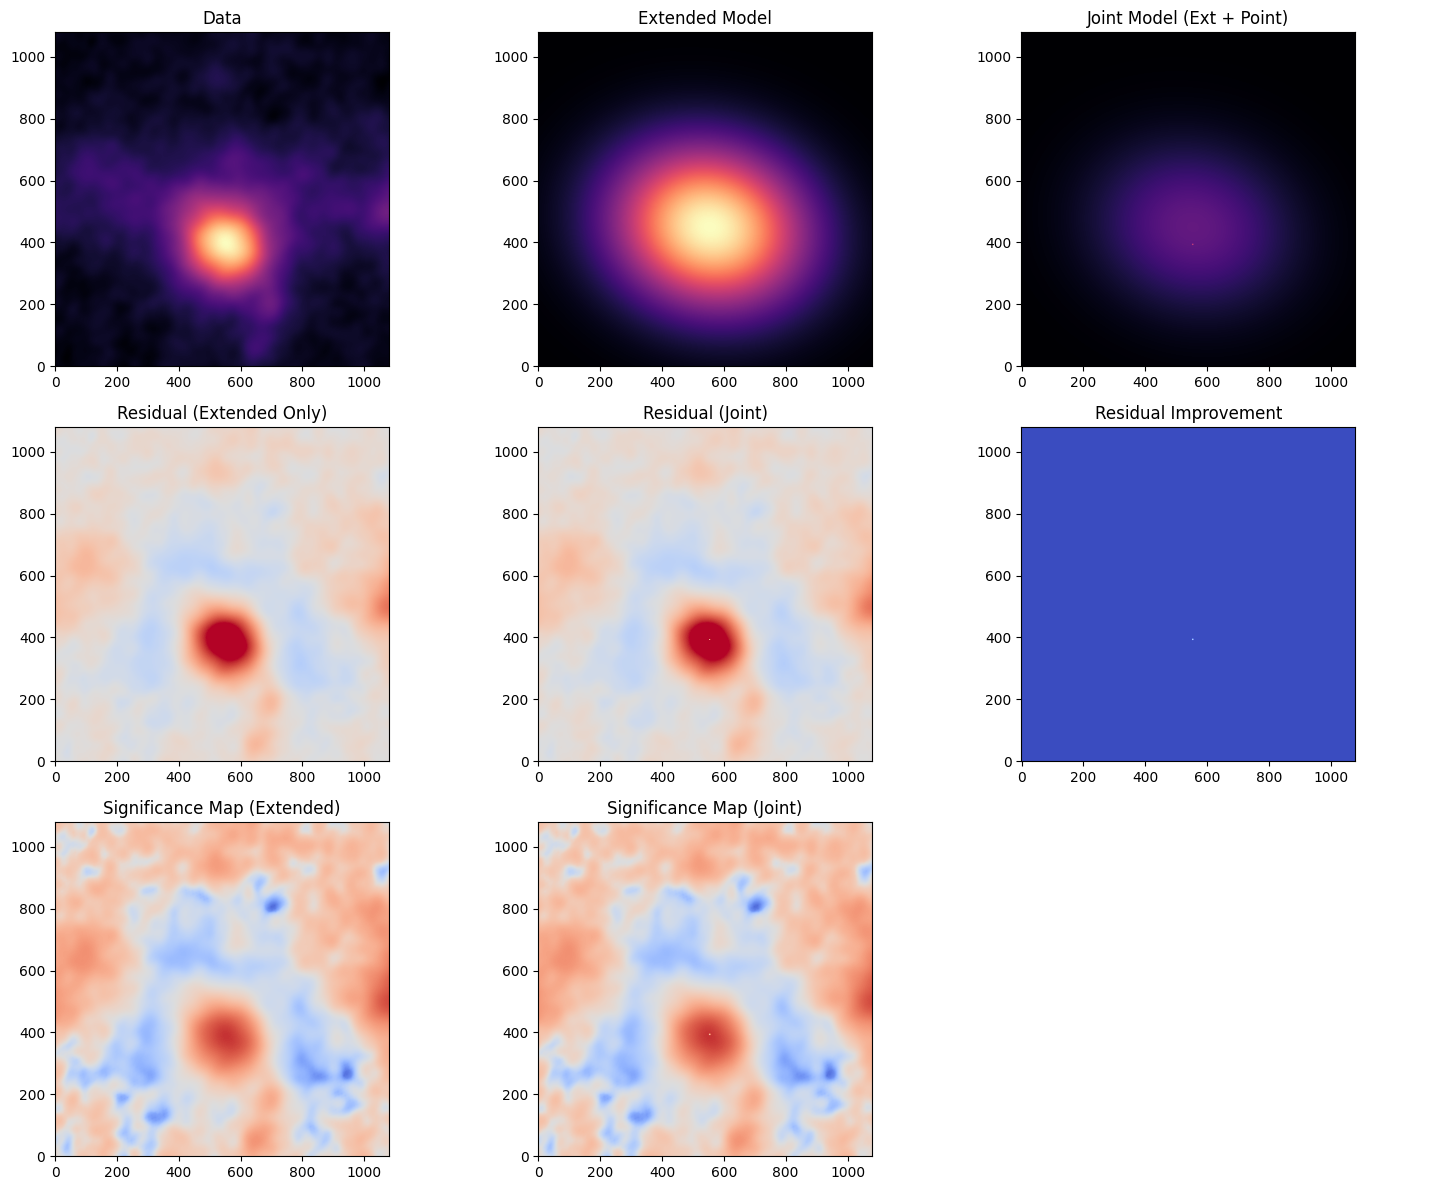

In [295]:
################################################################################
#  JUPYTER NOTEBOOK: EXTENDED-ONLY vs EXTENDED+POINT FITTING
#  Performs:
#     - 2D Gaussian fit to extended emission
#     - Joint fit (extended + point source)
#     - Δχ², AIC, ΔAIC
#     - Residual and significance maps
################################################################################

import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import Gaussian2D
from scipy.ndimage import gaussian_filter
from scipy.optimize import least_squares

# If your noise map exists, load it; otherwise assume Poisson sqrt(N)
# noise = np.sqrt(image)
################################################################################
# STEP 1 — LOAD IMAGE
################################################################################

# Replace this with your HAWC bin map (2D numpy array)
# e.g. image = fits.getdata("map.fits")[0]
image = array  # <-- Replace
noise = np.sqrt(np.maximum(image, 1.0))

ny, nx = image.shape
y, x = np.mgrid[0:ny, 0:nx]


################################################################################
# STEP 2 — EXTENDED-ONLY MODEL
################################################################################

def make_extended_model(params):
    """2D Gaussian extended source."""
    A, x0, y0, sx, sy, theta = params
    model = Gaussian2D(A, x0, y0, sx, sy, theta)(x, y)
    return model

def residuals_extended(params, data, noise):
    model = make_extended_model(params)
    # flatten 2D array to 1D for least_squares
    return ((model - data) / noise).ravel()


# Initial guess
A0 = image.max()
y0_guess, x0_guess = np.unravel_index(image.argmax(), image.shape)
guess_ext = [A0, x0_guess, y0_guess, 8, 8, 0.0]

res_ext = least_squares(residuals_extended, guess_ext, args=(image, noise))
best_ext = res_ext.x
model_ext = make_extended_model(best_ext)
residual_ext = image - model_ext

print("Extended-only parameters:", best_ext)


################################################################################
# STEP 3 — JOINT MODEL: EXTENDED + POINT SOURCE
################################################################################

def psf_convolve_point(xp, yp, amp, shape, fwhm_pix=1.5):
    """Create PSF-convolved point source."""
    sigma = fwhm_pix / 2.355
    pt = np.zeros(shape)
    iy, ix = int(round(yp)), int(round(xp))
    if 0 <= ix < shape[1] and 0 <= iy < shape[0]:
        pt[iy, ix] = amp
    return gaussian_filter(pt, sigma=sigma)

def make_joint_model(params):
    """
    params:
        [A, x0, y0, sx, sy, theta, A_pt, x_pt, y_pt]
    """
    A, x0, y0, sx, sy, theta, A_pt, xp, yp = params
    g = Gaussian2D(A, x0, y0, sx, sy, theta)(x, y)
    p = psf_convolve_point(xp, yp, A_pt, image.shape, fwhm_pix=2.5)
    return g + p

def residuals_joint(params, data, noise):
    return ((make_joint_model(params) - data) / noise).ravel()


# Initial guess for point source:
# look for brightest residual from extended fit
resid = residual_ext
yp_guess, xp_guess = np.unravel_index(np.abs(resid).argmax(), image.shape)
Apt_guess = resid[yp_guess, xp_guess]

guess_joint = list(best_ext) + [Apt_guess, xp_guess, yp_guess]

res_joint = least_squares(residuals_joint, guess_joint, args=(image, noise))
best_joint = res_joint.x
model_joint = make_joint_model(best_joint)
residual_joint = image - model_joint

print("Joint-fit parameters:", best_joint)


################################################################################
# STEP 4 — AIC, ΔAIC, CHI2 COMPUTATION
################################################################################

# χ² = sum (residual/noise)^2
chi2_ext = np.sum(residuals_extended(best_ext, image, noise)**2)
chi2_joint = np.sum(residuals_joint(best_joint, image, noise)**2)

k_ext = len(best_ext)             # number of parameters
k_joint = len(best_joint)

AIC_ext = 2*k_ext + chi2_ext
AIC_joint = 2*k_joint + chi2_joint
dAIC = AIC_ext - AIC_joint

print("χ² extended:", chi2_ext)
print("χ² joint:", chi2_joint)
print("AIC extended:", AIC_ext)
print("AIC joint:", AIC_joint)
print("ΔAIC (positive favors joint):", dAIC)


################################################################################
# STEP 5 — SIGNIFICANCE MAPS
################################################################################

sig_ext = residual_ext / noise
sig_joint = residual_joint / noise


################################################################################
# STEP 6 — VISUALIZATION
################################################################################

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Row 1: models
axes[0,0].imshow(image, origin="lower", cmap="magma")
axes[0,0].set_title("Data")
axes[0,1].imshow(model_ext, origin="lower", cmap="magma")
axes[0,1].set_title("Extended Model")
axes[0,2].imshow(model_joint, origin="lower", cmap="magma")
axes[0,2].set_title("Joint Model (Ext + Point)")

# Row 2: residuals
reslim = np.percentile(np.abs(residual_joint), 99)
axes[1,0].imshow(residual_ext, origin="lower", cmap="coolwarm", vmin=-reslim, vmax=reslim)
axes[1,0].set_title("Residual (Extended Only)")
axes[1,1].imshow(residual_joint, origin="lower", cmap="coolwarm", vmin=-reslim, vmax=reslim)
axes[1,1].set_title("Residual (Joint)")
axes[1,2].imshow(residual_ext - residual_joint, origin="lower", cmap="coolwarm")
axes[1,2].set_title("Residual Improvement")

# Row 3: significance
siglim = 5
axes[2,0].imshow(sig_ext, origin="lower", cmap="coolwarm", vmin=-siglim, vmax=siglim)
axes[2,0].set_title("Significance Map (Extended)")
axes[2,1].imshow(sig_joint, origin="lower", cmap="coolwarm", vmin=-siglim, vmax=siglim)
axes[2,1].set_title("Significance Map (Joint)")
axes[2,2].axis("off")

plt.tight_layout()
plt.show()
